In [105]:
import pandas as pd

import os, sys
import matplotlib.pyplot as plt

sys.path.insert(0, "../../")

from spec.enums import MainTableColumns as Cols

In [106]:
# base_dir = '../../../sample_data/cwo/s19/analysis/'
base_dir = '../../../sample_data/cwo/f19/analysis/'
# base_dir = '../../../sample_data/codebench/2024/analysis/'

In [107]:
data = pd.read_csv(os.path.join(base_dir, 'subject_features.csv'))

In [108]:
data.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,EndTime_sum,Attempts_sum,FirstCorrect_sum,EverCorrect_sum,Attempted_sum,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,Grade
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,-0.681976,0.487998,-0.073142,-0.350969,-0.674883,-0.804204,0.394493,-0.887989,-0.681731,...,-0.900034,-0.711357,0.461610,0.513218,0.288621,0.379840,0.153132,0.154288,-0.742688,59.38
1,014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...,-0.987288,-0.215226,-0.642284,-0.260234,2.242589,0.362448,0.394703,0.423574,-0.667995,...,0.453063,-0.696985,0.461610,0.513218,0.288621,0.379840,0.210509,0.317162,-0.668508,97.00
2,01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...,-0.509997,-0.083696,-0.304745,-0.337422,-0.649447,-0.298122,-0.583139,-0.358422,-0.469185,...,-0.318327,-0.440081,-0.025004,-1.021582,-0.500796,-0.280230,-0.090171,0.092723,-0.471707,59.46
3,03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...,0.284194,1.185366,0.824161,0.115663,0.835450,-0.226237,0.174257,-0.172618,-0.046126,...,-0.162009,-0.046350,0.948224,0.206258,0.288621,0.232606,1.364680,1.215246,0.031669,73.05
4,0461c96c9cc0058f709704605f24136f373ba4e9ac083a...,0.720114,-0.625583,0.027841,-0.344196,0.217321,-3.018662,0.199387,-2.924160,-0.170250,...,-2.850652,-0.167405,-0.754925,-0.100702,-0.106088,0.155982,-0.092482,0.201491,-0.207871,73.13


In [109]:
X = data.drop(columns=[Cols.SubjectID, 'Grade'])
y = data['Grade']

In [110]:
# Drop columns with 0 variance
variance = X.var()
zero_variance_cols = variance[variance == 0].index
print (f"Dropping columns with zero variance: {zero_variance_cols.tolist()}")
X = X.drop(columns=zero_variance_cols)

Dropping columns with zero variance: ['Attempted_mean']


In [111]:
linear_corr = X.corr()
# Find pairs that have correlation above 0.9
corr_pairs = linear_corr[linear_corr != 1].stack().reset_index()
corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
high_corr_pairs = corr_pairs[abs(corr_pairs['Correlation']) > 0.9].reset_index(drop=True)
print("High correlation pairs:")
with pd.option_context('display.max_rows', None):
    print(high_corr_pairs)

High correlation pairs:
                       Feature1                     Feature2  Correlation
0               ActiveTime_mean                Attempts_mean     0.952920
1               ActiveTime_mean           TotalAttempts_mean     0.950012
2               ActiveTime_mean               ActiveTime_sum     0.988878
3               ActiveTime_mean                 Attempts_sum     0.943571
4               ActiveTime_mean            TotalAttempts_sum     0.941101
5              PassiveTime_mean               TotalTime_mean     0.908378
6              PassiveTime_mean              PassiveTime_sum     0.981109
7                TotalTime_mean             PassiveTime_mean     0.908378
8                TotalTime_mean              PassiveTime_sum     0.900160
9                TotalTime_mean                TotalTime_sum     0.984369
10  ActiveTimeAfterCorrect_mean   ActiveTimeAfterCorrect_sum     0.986816
11                 #Breaks_mean                  #Breaks_sum     0.994430
12            

<Axes: >

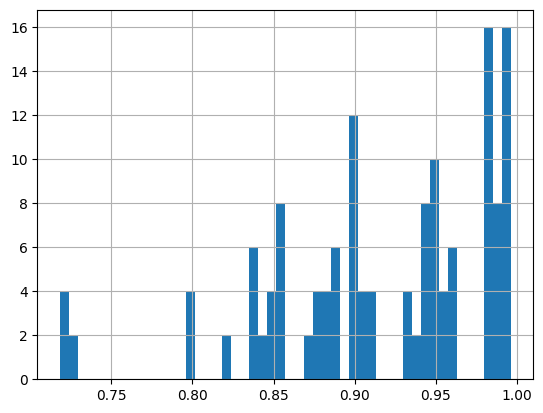

In [112]:
corr_pairs.Correlation[corr_pairs.Correlation > 0.7].hist(bins=50)

In [113]:
# For each highly correlated pair of features, drop the one with the lower
# correlation with the target variable
def drop_low_corr_feature(pair, X, y):
    feature1, feature2 = pair['Feature1'], pair['Feature2']
    corr1 = X[feature1].corr(y)
    corr2 = X[feature2].corr(y)
    if abs(corr1) > abs(corr2):
        return feature2
    else:
        return feature1

to_drop = high_corr_pairs.apply(drop_low_corr_feature, axis=1, X=X, y=y)
print(f"Dropping features with high correlation: {to_drop.tolist()}")
X_lean = X.drop(columns=to_drop)

Dropping features with high correlation: ['Attempts_mean', 'ActiveTime_mean', 'ActiveTime_mean', 'ActiveTime_mean', 'ActiveTime_mean', 'PassiveTime_mean', 'PassiveTime_sum', 'PassiveTime_mean', 'PassiveTime_sum', 'TotalTime_sum', 'ActiveTimeAfterCorrect_mean', '#Breaks_sum', 'StartTime_mean', 'StartTime_mean', 'StartTime_mean', 'EverCorrect_mean', 'FirstCorrectTime_sum', 'StartTime_mean', 'StartTime_sum', 'EndTime_mean', 'Attempts_mean', 'Attempts_mean', 'Attempts_mean', 'Attempts_mean', 'Attempts_mean', 'MinScore_mean', 'FirstCorrect_sum', 'MinScore_sum', 'EverCorrect_mean', 'MinScore_mean', 'MinScore_mean', 'MinScore_mean', 'MinScore_mean', 'MinScore_mean', 'MinScore_mean', 'MinScore_sum', 'MeanScore_sum', 'ActiveTime_mean', 'Attempts_mean', 'ActiveTime_sum', 'Attempts_sum', 'TotalAttempts_mean', 'ActiveTime_mean', 'Attempts_mean', 'ActiveTime_sum', 'ActiveTime_sum', 'Attempts_sum', 'ActiveTime_sum', 'PassiveTime_sum', 'PassiveTime_sum', 'PassiveTime_sum', 'TotalTime_sum', 'ActiveTim

In [114]:
X_lean.columns

Index(['TotalTime_mean', '#Breaks_mean', 'FirstCorrectTime_mean',
       'FirstCorrect_mean', 'MaxScore_mean', 'MeanScore_mean',
       'ActiveTimeAfterCorrect_sum', 'EndTime_sum', 'EverCorrect_sum',
       'Attempted_sum', 'MaxScore_sum', 'TotalAttempts_sum'],
      dtype='object')

In [115]:
data.drop(columns=to_drop).drop(columns=[Cols.SubjectID]).corr(method='spearman')

,TotalTime_mean,#Breaks_mean,FirstCorrectTime_mean,FirstCorrect_mean,Attempted_mean,MaxScore_mean,MeanScore_mean,ActiveTimeAfterCorrect_sum,EndTime_sum,EverCorrect_sum,Attempted_sum,MaxScore_sum,TotalAttempts_sum,Grade
TotalTime_mean,1.000000,0.664923,-0.180912,-0.673249,NaN,-0.193766,-0.756627,0.231071,0.034851,-0.172526,-0.018971,-0.184851,0.888799,-0.131117
#Breaks_mean,0.664923,1.000000,-0.186093,-0.515633,NaN,-0.204011,-0.565654,0.170577,-0.003378,-0.148666,0.033452,-0.173399,0.642524,-0.095983
FirstCorrectTime_mean,-0.180912,-0.186093,1.000000,0.264549,NaN,0.869246,0.292592,0.027507,0.254331,0.829271,0.314265,0.857153,-0.198496,-0.028747
FirstCorrect_mean,-0.673249,-0.515633,0.264549,1.000000,NaN,0.265388,0.894108,-0.138701,-0.034685,0.252247,0.103625,0.254498,-0.763086,0.005292
Attempted_mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaxScore_mean,-0.193766,-0.204011,0.869246,0.265388,NaN,1.000000,0.328815,0.025333,-0.102454,0.894952,0.333162,0.957357,-0.203984,0.083481
MeanScore_mean,-0.756627,-0.565654,0.292592,0.894108,NaN,0.328815,1.000000,-0.183628,-0.081381,0.302938,0.139872,0.314637,-0.840466,0.129730
ActiveTimeAfterCorrect_sum,0.231071,0.170577,0.027507,-0.138701,NaN,0.025333,-0.183628,1.000000,0.040977,-0.044643,-0.248356,-0.005839,0.322703,-0.156286
EndTime_sum,0.034851,-0.003378,0.254331,-0.034685,NaN,-0.102454,-0.081381,0.040977,1.000000,-0.090288,-0.035994,-0.109031,0.036110,-0.266725
EverCorrect_sum,-0.172526,-0.148666,0.829271,0.252247,NaN,0.894952,0.302938,-0.044643,-0.090288,1.000000,0.550951,0.972155,-0.209911,0.072108


In [116]:
X_lean.corr()

,TotalTime_mean,#Breaks_mean,FirstCorrectTime_mean,FirstCorrect_mean,MaxScore_mean,MeanScore_mean,ActiveTimeAfterCorrect_sum,EndTime_sum,EverCorrect_sum,Attempted_sum,MaxScore_sum,TotalAttempts_sum
TotalTime_mean,1.000000,0.598618,-0.196028,-0.548953,-0.102525,-0.648315,0.136571,0.067217,-0.155565,-0.056422,-0.191787,0.835700
#Breaks_mean,0.598618,1.000000,-0.107037,-0.381762,-0.042357,-0.462128,0.093017,0.052594,-0.069231,0.037213,-0.113696,0.649939
FirstCorrectTime_mean,-0.196028,-0.107037,1.000000,0.275922,0.888677,0.401345,0.061869,-0.104928,0.799773,0.467315,0.877449,-0.170826
FirstCorrect_mean,-0.548953,-0.381762,0.275922,1.000000,0.222064,0.899197,-0.023520,-0.014490,0.225515,0.097554,0.239590,-0.654179
MaxScore_mean,-0.102525,-0.042357,0.888677,0.222064,1.000000,0.362387,0.032132,-0.070718,0.723573,0.534086,0.821909,-0.098728
MeanScore_mean,-0.648315,-0.462128,0.401345,0.899197,0.362387,1.000000,-0.062368,-0.100623,0.338562,0.179970,0.377508,-0.753831
ActiveTimeAfterCorrect_sum,0.136571,0.093017,0.061869,-0.023520,0.032132,-0.062368,1.000000,0.029492,0.034481,-0.021685,0.045960,0.206814
EndTime_sum,0.067217,0.052594,-0.104928,-0.014490,-0.070718,-0.100623,0.029492,1.000000,-0.106875,-0.068753,-0.104079,0.075607
EverCorrect_sum,-0.155565,-0.069231,0.799773,0.225515,0.723573,0.338562,0.034481,-0.106875,1.000000,0.845535,0.718513,-0.142645
Attempted_sum,-0.056422,0.037213,0.467315,0.097554,0.534086,0.179970,-0.021685,-0.068753,0.845535,1.000000,0.362200,-0.037818


In [117]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_lean, y, test_size=0.2, random_state=42)

In [118]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200, 350, 500],
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error')

grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)

Best parameters found:  {'n_estimators': 200}


In [119]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train, y_train)
print("Lasso coefficients: ", lasso.coef_)
print("Lasso intercept: ", lasso.intercept_)


Lasso coefficients:  [ -1.32032166   0.           3.72053044 -11.12139712  -0.
   7.60946723  -1.35237936  -3.42361455  -0.          -1.03317922
  -1.65297985  -1.99830209]
Lasso intercept:  61.883091387655284


In [120]:
from sklearn.metrics import root_mean_squared_error

root_mean_squared_error(y_test, grid_search.predict(X_test))

15.897706092779517

In [121]:
root_mean_squared_error(y_test, lasso.predict(X_test))

14.812012061779791

In [122]:
from sklearn.dummy import DummyRegressor

dummy_regressor = DummyRegressor(strategy='mean')
dummy_regressor.fit(X_train, y_train)
root_mean_squared_error(y_test, dummy_regressor.predict(X_test))

17.483980768232737

<Axes: >

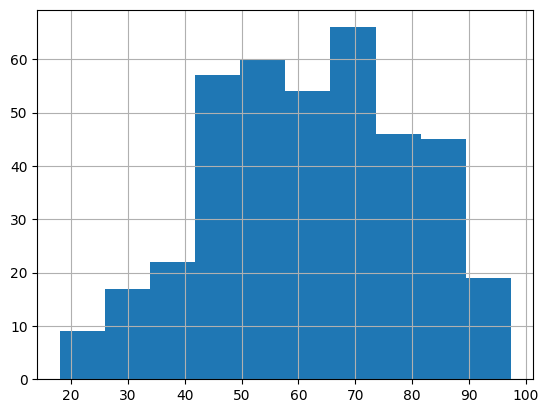

In [123]:
y_train.hist()